# Visualización de resultados

## Equipo 74  
* Diana Jimena López Nájera
* Marcelo Ismael López Verdugo
* Salma Alejandra Macías Rosas
* Dario Maximiliano Mendoza Orozco

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, avg, when, isnan, lit, desc, hour, dayofmonth, dayofweek
from pyspark.sql.functions import split, regexp_extract
from pyspark.sql.functions import collect_set, countDistinct, collect_list
from pyspark.sql.types import DoubleType, FloatType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import DecisionTreeRegressor, GBTRegressor
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator




spark = SparkSession.builder \
    .appName("Analisis Ecommerce Octubre") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

spark

## Directorio del dataset

In [2]:
root=".."
file_path = root + "/datasets/2019-Oct.csv"

df = spark.read.option("header", True) \
               .option("inferSchema", True) \
               .csv(file_path)

df.show(5, truncate=False)

+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price  |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|2019-09-30 17:00:00|view      |44600062  |2103807459595387724|NULL                               |shiseido|35.79  |541312140|72d76fde-8bb3-4e00-8c23-a032dfed738c|
|2019-09-30 17:00:00|view      |3900821   |2053013552326770905|appliances.environment.water_heater|aqua    |33.2   |554748717|9333dfbd-b87a-4708-9857-6336556b0fcc|
|2019-09-30 17:00:01|view      |17200506  |2053013559792632471|furniture.living_room.sofa         |NULL    |543.1  |519107250|566511c2-e2e3-422b-b695-cf8e6e792ca8|
|2019-09-30 17:0

In [3]:
df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



# Depuración y preparación

## Análisis de cardinalidad
Es útil conocer cuantos valores únicos existen por columna para identificar potenciales particionamientos

In [4]:
df_clean = df.dropna()
df_clean = df_clean.withColumn("weekhour", dayofweek(col("event_time")) + hour(col("event_time")) / 24)

non_numeric_columns = [name for name, dtype in df_clean.dtypes if dtype == "string"]
for col_name in non_numeric_columns:
    distinct_count = df_clean.select(col_name).distinct().count()
    print(f"{col_name}: dtype=string, distinct={distinct_count}")

    top_values = [row[col_name] for row in df_clean.groupBy(col_name)
                                              .count()
                                              .orderBy(desc("count"))
                                              .limit(10)
                                              .select(col_name)
                                              .collect()]

    grouped_col = f"{col_name}_grouped"
    df_clean = df_clean.withColumn(
        grouped_col,
        when(col(col_name).isin(top_values), col(col_name)).otherwise(lit("other"))
    )

print("Columnas agrupadas creadas:", [f"{c}_grouped" for c in non_numeric_columns])

df_clean.describe().show()

event_type: dtype=string, distinct=3
category_code: dtype=string, distinct=126
brand: dtype=string, distinct=1731
user_session: dtype=string, distinct=6419693
Columnas agrupadas creadas: ['event_type_grouped', 'category_code_grouped', 'brand_grouped', 'user_session_grouped']
+-------+----------+-----------------+--------------------+-------------------+--------+-----------------+--------------------+--------------------+------------------+------------------+---------------------+-------------+--------------------+
|summary|event_type|       product_id|         category_id|      category_code|   brand|            price|             user_id|        user_session|          weekhour|event_type_grouped|category_code_grouped|brand_grouped|user_session_grouped|
+-------+----------+-----------------+--------------------+-------------------+--------+-----------------+--------------------+--------------------+------------------+------------------+---------------------+-------------+--------------

In [5]:
#Valores únicos por variable
columns_to_check = ["product_id", "category_id", "category_code", "brand", "user_id", "user_session"]

for c in columns_to_check:
    print(f"{c}: {df.select(c).distinct().count():,} valores únicos")

product_id: 166,794 valores únicos
category_id: 624 valores únicos
category_code: 127 valores únicos
brand: 3,446 valores únicos
user_id: 3,022,290 valores únicos
user_session: 9,244,422 valores únicos


# Uso de clusters para generación de categorías de usuario  
## "Entrenamiento no supervisado"  
En cuanto a generar recomendaciones para usuarios es posible hacer un sistema de recomendaciones a partir de matrices dispersas.  Se almacena una categorización de acuerdo a tales clusters de usuario convirtiendo la gran cantidad de usuarios en solo un tipo o categoría.  A partir de tal categorías se pueden generar proyecciones de ventas o sugerencias para anuncios

In [6]:
## Clustering de clientes por usuario
# Agrupamos por user_id y calculamos métricas de interacción y precio.
user_features = (
    df_clean
    .groupBy("user_id")
    .agg(
        count("*").alias("interactions"),
        sum("price").alias("total_spend"),
        avg("price").alias("avg_price"),
        countDistinct("brand").alias("brand_diversity"),
        collect_list("brand").alias("brand_list")
    )
)

user_features.show(10, truncate=False)

# Vectorizamos las marcas con sparse features usando CountVectorizer.
from pyspark.ml.feature import CountVectorizer, StandardScaler
from pyspark.ml.clustering import KMeans

cv = CountVectorizer(inputCol="brand_list", outputCol="brand_vec", vocabSize=100, minDF=2.0)
assembler = VectorAssembler(
    inputCols=["interactions", "total_spend", "avg_price", "brand_diversity", "brand_vec"],
    outputCol="raw_features"
)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)

pipeline = Pipeline(stages=[cv, assembler, scaler])
pipeline_model = pipeline.fit(user_features)
user_vector = pipeline_model.transform(user_features)

# Entrenamos KMeans y asignamos un segmento de cliente.
k = 4
kmeans = KMeans(k=k, featuresCol="features", predictionCol="customer_segment", seed=42)
kmeans_model = kmeans.fit(user_vector)
clustered_users = kmeans_model.transform(user_vector)

clustered_users.select(
    "user_id", "customer_segment", "interactions", "total_spend", "avg_price", "brand_diversity"
).show(20, truncate=False)

# Agregamos la categoría al dataset original para análisis posterior.
df_with_segment = df_clean.join(
    clustered_users.select("user_id", "customer_segment"),
    on="user_id",
    how="left"
)

print("Distribución de segmentos de cliente:")
df_with_segment.groupBy("customer_segment").count().orderBy("customer_segment").show()

# Opcional: ver centros de los clústeres.
print("Centros de cluster:")
for idx, center in enumerate(kmeans_model.clusterCenters()):
    print(f"Cluster {idx}: {center}")


+---------+------------+------------------+------------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id  |interactions|total_spend       |avg_price         |brand_diversity|brand_list                                                                                                                                                                                                                                        |
+---------+------------+------------------+------------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|240522111|34          |7215.24000

# Visualización de clusters

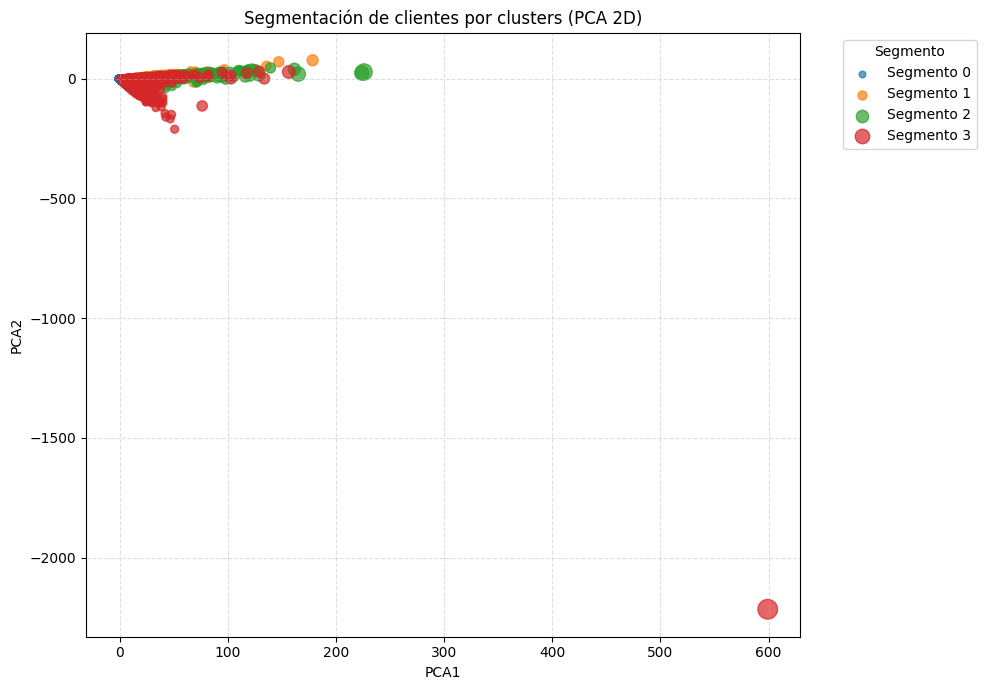

Total de usuarios visualizados: 2323036


In [7]:
# Reducción de dimensionalidad con PCA para visualización 2D
from pyspark.ml.feature import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Aplicar PCA a 2 componentes para visualizar
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(user_vector)
user_pca = pca_model.transform(user_vector)

# Unir clustered_users con user_pca para recuperar customer_segment
user_pca_with_segment = user_pca.join(
    clustered_users.select("user_id", "customer_segment"),
    on="user_id",
    how="left"
)

# Extraer componentes PCA y segmentos para visualización
viz_data = user_pca_with_segment.select(
    "user_id", "customer_segment", "interactions", "total_spend", "pca_features"
).collect()

# Convertir a pandas para visualización
pca_list = []
for row in viz_data:
    pca_list.append({
        "user_id": row["user_id"],
        "segment": row["customer_segment"],
        "interactions": row["interactions"],
        "total_spend": row["total_spend"],
        "PCA1": float(row["pca_features"][0]),
        "PCA2": float(row["pca_features"][1])
    })

if not pca_list:
    print("No hay datos para visualizar.")
else:
    df_viz = pd.DataFrame(pca_list)

    # Calcular tamaños de puntos basados en interacciones
    interactions = df_viz["interactions"].astype(float)
    size_min, size_max = 20, 200
    sizes = size_min + (interactions - interactions.min()) / (interactions.max() - interactions.min() + 1e-9) * (size_max - size_min)

    fig, ax = plt.subplots(figsize=(10, 7))
    for segment in sorted(df_viz["segment"].unique()):
        subset = df_viz[df_viz["segment"] == segment]
        ax.scatter(
            subset["PCA1"],
            subset["PCA2"],
            s=sizes[subset.index],
            alpha=0.7,
            label=f"Segmento {segment}"
        )

    ax.set_title("Segmentación de clientes por clusters (PCA 2D)")
    ax.set_xlabel("PCA1")
    ax.set_ylabel("PCA2")
    ax.legend(title="Segmento", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"Total de usuarios visualizados: {len(df_viz)}")


Estadísticas por segmento de cliente:
+----------------+---------+-----------------+------------------+------------------+-------------------+
|customer_segment|num_users|avg_interactions |avg_total_spend   |avg_price         |avg_brand_diversity|
+----------------+---------+-----------------+------------------+------------------+-------------------+
|0               |2234983  |8.046203483426943|2868.758987826692 |373.70122496606   |2.474888175883217  |
|1               |11191    |88.86909123402734|15547.409101956931|148.84443124722176|15.322133857564115 |
|2               |66637    |100.5682878881102|38431.87893992829 |387.9790187016921 |12.977504989720426 |
|3               |10225    |86.19941320293398|22055.71915207824 |246.6399187725648 |13.454278728606356 |
+----------------+---------+-----------------+------------------+------------------+-------------------+



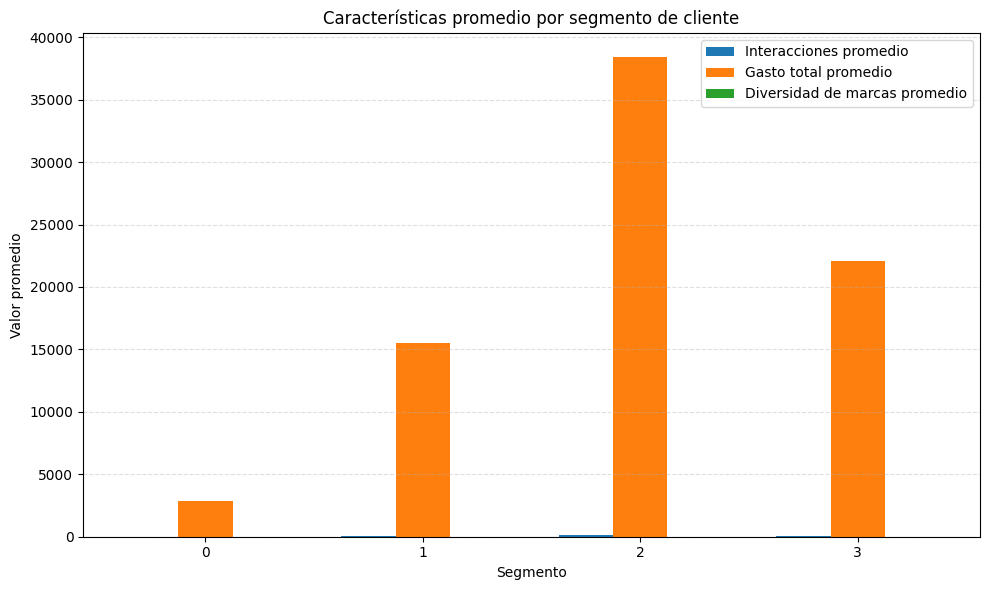

In [9]:
# Análisis de características por cluster
cluster_stats = (
    clustered_users
    .groupBy("customer_segment")
    .agg(
        count("*").alias("num_users"),
        avg("interactions").alias("avg_interactions"),
        avg("total_spend").alias("avg_total_spend"),
        avg("avg_price").alias("avg_price"),
        avg("brand_diversity").alias("avg_brand_diversity")
    )
    .orderBy("customer_segment")
)

print("Estadísticas por segmento de cliente:")
cluster_stats.show(truncate=False)

# Visualizar estadísticas por cluster
stats_df = cluster_stats.toPandas()

# Gráfico de barras con matplotlib
fig2, ax2 = plt.subplots(figsize=(10, 6))
bar_width = 0.25
indices = range(len(stats_df))

ax2.bar([i - bar_width for i in indices], stats_df["avg_interactions"], width=bar_width, label="Interacciones promedio")
ax2.bar(indices, stats_df["avg_total_spend"], width=bar_width, label="Gasto total promedio")
ax2.bar([i + bar_width for i in indices], stats_df["avg_brand_diversity"], width=bar_width, label="Diversidad de marcas promedio")

ax2.set_xticks(indices)
ax2.set_xticklabels(stats_df["customer_segment"].astype(str))
ax2.set_xlabel("Segmento")
ax2.set_ylabel("Valor promedio")
ax2.set_title("Características promedio por segmento de cliente")
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
